In [1]:
from pathlib import Path
import os
from contextlib import contextmanager
from IPython import get_ipython

@contextmanager
def safe_chdir(target):
    prev_dir = Path.cwd()
    os.chdir(target)
    try:
        yield Path.cwd()
    finally:
        os.chdir(prev_dir)

file_dir = Path(get_ipython().run_line_magic('pwd', '')).resolve()
target_dir = file_dir / "../.."
with safe_chdir(target_dir):
    import src


In [6]:
import json
from src.utils.const import ARTIFACTS_PATH
from src.eval.codec import Codec

In [14]:
with open(str(ARTIFACTS_PATH/"data.json"), "r", encoding="utf-8") as f:
    codecs_dicts = json.load(f)

classic_codecs = []
neural_codecs = []
for c_dict in codecs_dicts:
    codec = Codec(**c_dict)
    if codec.type != "classic":
        neural_codecs.append(codec)
    if codec.type != "neural":
        classic_codecs.append(codec)

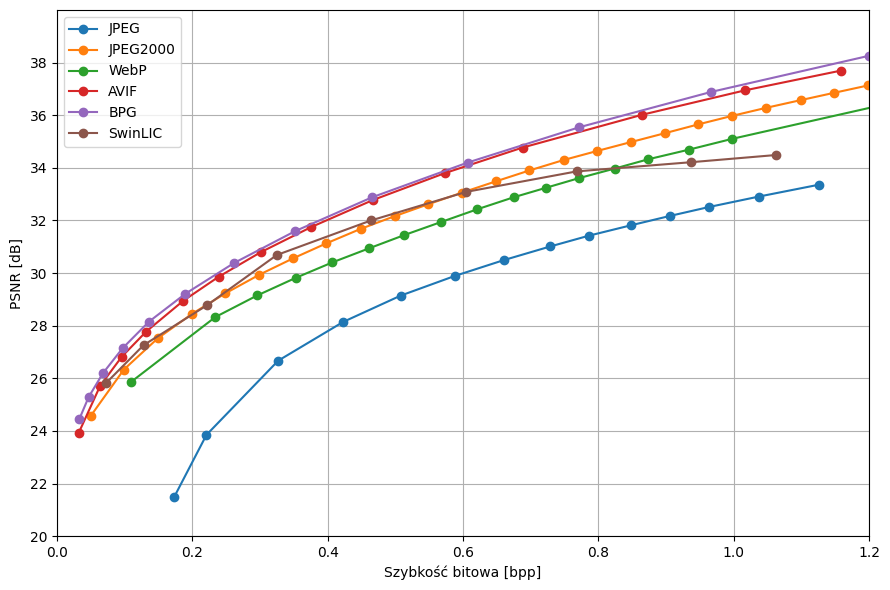

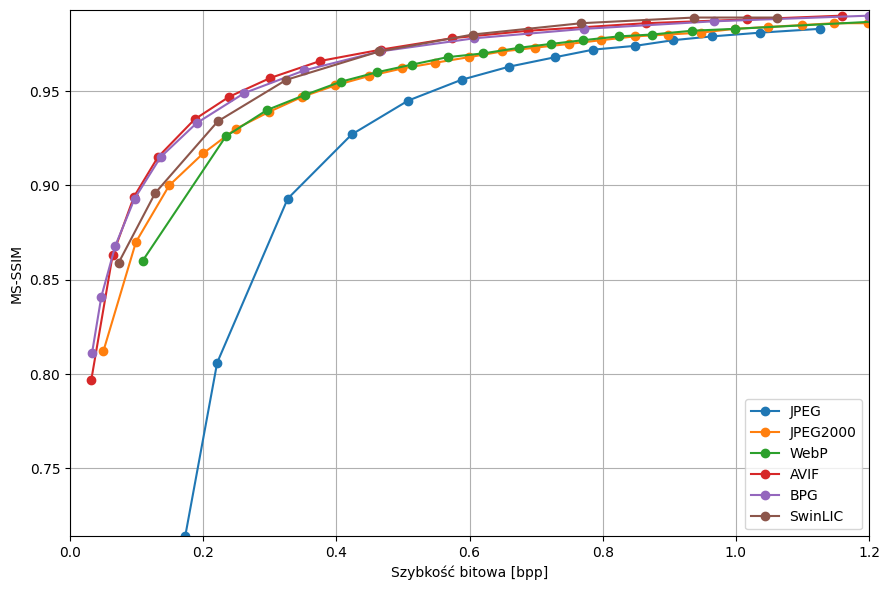

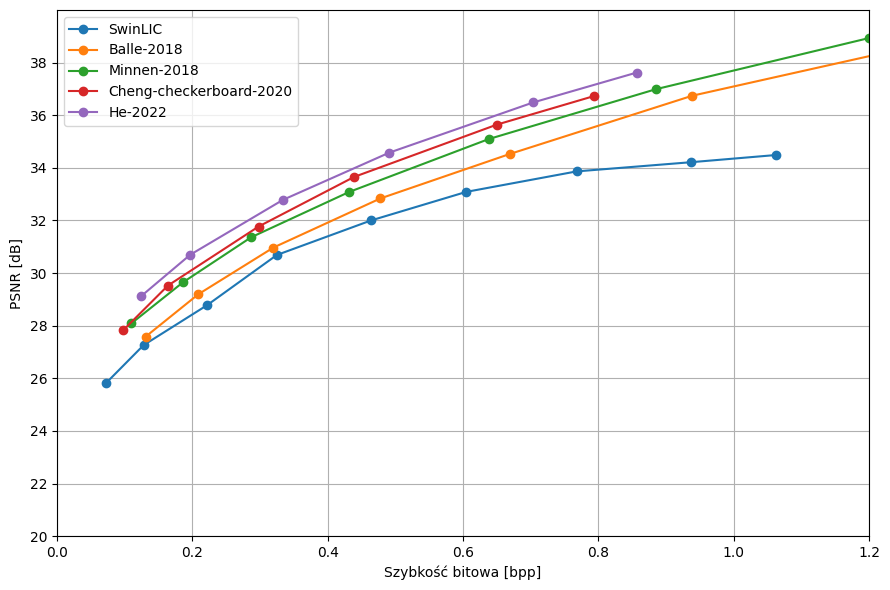

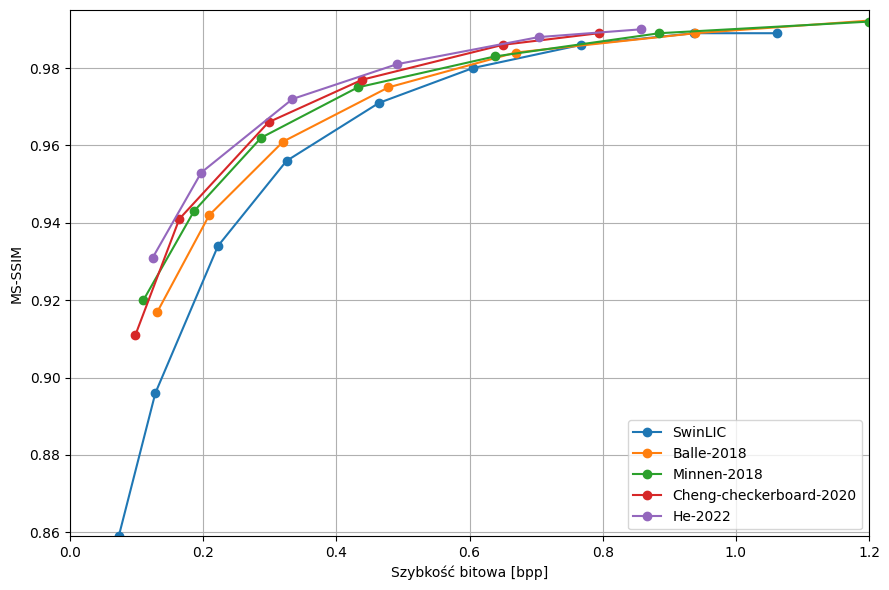

In [15]:
from datetime import datetime, timezone
from matplotlib import pyplot as plt

artifacts_dir = ARTIFACTS_PATH / (datetime.now(timezone.utc).strftime("%Y%m%dT%H%M") + "-14")
artifacts_dir.mkdir(parents=True, exist_ok=True)

px = 1/plt.rcParams['figure.dpi']  # pixel in inches

plt.figure(figsize=(900*px, 600*px))
plt.style.use('default')
for codec in classic_codecs:
    plt.plot(codec.bpp, codec.psnr, label=codec.label, marker='o')
plt.grid(True)
plt.legend()
plt.xlim(0, 1.2)
plt.ylim(20, 40)
plt.yticks(range(20, 40, 2))
plt.xlabel('Szybkość bitowa [bpp]')
plt.ylabel('PSNR [dB]')
plt.margins(0, 0)
plt.tight_layout()
plt.savefig(artifacts_dir / "classic_rd_psnr.png")

plt.figure(figsize=(900*px, 600*px))
plt.style.use('default')
for codec in classic_codecs:
    plt.plot(codec.bpp, codec.msssim, label=codec.label, marker='o')
plt.grid(True)
plt.legend()
plt.xlim(0, 1.2)
plt.xlabel('Szybkość bitowa [bpp]')
plt.ylabel('MS-SSIM')
plt.margins(0, 0)
plt.tight_layout()
plt.savefig(artifacts_dir / "classic_rd_ms_ssim.png")

plt.figure(figsize=(900*px, 600*px))
plt.style.use('default')
for codec in neural_codecs:
    plt.plot(codec.bpp, codec.psnr, label=codec.label, marker='o')
plt.grid(True)
plt.legend()
plt.xlim(0, 1.2)
plt.ylim(20, 40)
plt.yticks(range(20, 40, 2))
plt.xlabel('Szybkość bitowa [bpp]')
plt.ylabel('PSNR [dB]')
plt.margins(0, 0)
plt.tight_layout()
plt.savefig(artifacts_dir / "neural_rd_psnr.png")

plt.figure(figsize=(900*px, 600*px))
plt.style.use('default')
for codec in neural_codecs:
    plt.plot(codec.bpp, codec.msssim, label=codec.label, marker='o')
plt.grid(True)
plt.legend()
plt.xlim(0, 1.2)
plt.xlabel('Szybkość bitowa [bpp]')
plt.ylabel('MS-SSIM')
plt.margins(0, 0)
plt.tight_layout()
plt.savefig(artifacts_dir / "neural_rd_ms_ssim.png")
